# AthleteAI — Notebook 2 : Analyse Exploratoire (EDA)

## Contexte
Ce notebook constitue la deuxième étape du projet AthleteAI. À partir du fichier `master_sessions.csv` généré dans le Notebook 1, on réalise une **analyse exploratoire complète** des données d'entraînement.

L'objectif est triple :
- **Comprendre la structure** des données (types, valeurs manquantes, distributions)
- **Identifier les tendances** sur 2 ans d'entraînement (saisonnalité, progression, régularité)
- **Détecter les corrélations** entre les variables pour préparer le Feature Engineering

## Dataset
- **Source** : `data/processed/master_sessions.csv`
- **Contenu** : ensemble des points GPS/cardiaques de toutes les séances
- **Variables** : `timestamp`, `distance`, `heart_rate`, `enhanced_speed`, `speed`, `cadence`, `activity_type`, `session_file`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style des graphiques
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Reds_r")

# Chargement
df = pd.read_csv("../data/processed/master_sessions.csv")
print(f"Dataset chargé : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")
df.head(-5)

Dataset chargé : 817,392 lignes, 16 colonnes


,activity_type,distance,timestamp,Effort Pace,enhanced_speed,speed,heart_rate,altitude,enhanced_altitude,step_length,cadence,accumulated_power,power,position_lat,position_long,session_file
0,running,0.0,2024-11-17 22:47:05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,464899027052298241.fit
1,running,0.0,2024-11-17 22:47:06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,464899027052298241.fit
2,running,0.0,2024-11-17 22:47:07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,464899027052298241.fit
3,running,0.0,2024-11-17 22:47:08,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,464899027052298241.fit
4,running,0.0,2024-11-17 22:47:09,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,464899027052298241.fit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817382,running,1999.0,2025-11-06 19:19:25,4.041,3.525,3.525,163.0,364.0,364.0,1230.0,86.0,174499.0,309.0,522929788.0,69006586.0,473105890568863846.fit
817383,running,2002.5,2025-11-06 19:19:26,4.041,3.528,3.528,163.0,364.0,364.0,1230.0,85.0,174808.0,309.0,522930156.0,69006433.0,473105890568863846.fit
817384,running,2006.0,2025-11-06 19:19:27,4.041,3.531,3.531,163.0,365.0,365.0,1240.0,85.0,175117.0,309.0,522930538.0,69006309.0,473105890568863846.fit
817385,running,2009.0,2025-11-06 19:19:28,4.041,3.531,3.531,163.0,365.0,365.0,1240.0,85.0,175426.0,309.0,522930919.0,69006185.0,473105890568863846.fit


## Étape 1 — Nettoyage et typage des données

Avant toute analyse, plusieurs opérations de nettoyage sont nécessaires :

1. **Conversion du timestamp** en datetime avec gestion du fuseau horaire Europe/Paris
2. **Extraction des dimensions temporelles** (année, mois, jour de la semaine, heure) pour les analyses de saisonnalité
3. **Conversion des unités** : distance en km, vitesse en km/h
4. **Suppression des valeurs aberrantes** : points sans fréquence cardiaque ou sans mouvement

> Ces étapes sont indispensables pour garantir la fiabilité des analyses suivantes.

In [2]:
# Convertir le timestamp en datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["timestamp"] = df["timestamp"].dt.tz_convert("Europe/Paris")

# Extraire les dimensions temporelles
df["date"]    = df["timestamp"].dt.date
df["year"]    = df["timestamp"].dt.year
df["month"]   = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.day_name()
df["hour"]    = df["timestamp"].dt.hour

# Convertir distance en km
df["distance_km"] = df["distance"] / 1000

# Convertir vitesse en km/h
df["speed_kmh"] = df["enhanced_speed"] * 3.6

# Supprimer les lignes sans FC ou sans distance
df = df.dropna(subset=["heart_rate", "distance"])
df = df[df["speed_kmh"] > 0]

print(f"Dataset nettoyé : {df.shape[0]:,} points")
print(f"Période : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Nombre de fichiers (séances) : {df['session_file'].nunique()}")

Dataset nettoyé : 727,215 points
Période : 2024-05-03 → 2026-01-31
Nombre de fichiers (séances) : 323


## Étape 2 — Agrégation par séance

Chaque fichier `.fit` contient des milliers de points enregistrés à la seconde. Pour analyser les **tendances globales**, on agrège ces points au niveau de la séance en calculant :

- La **distance totale** parcourue
- La **durée** de la séance
- La **fréquence cardiaque moyenne et maximale**
- La **vitesse moyenne** et l'**allure** (min/km)
- La **cadence moyenne**

Les séances de moins de 5 minutes ou moins de 500 mètres sont exclues car elles correspondent à des enregistrements accidentels.

In [3]:
# Agrégation par séance
sessions = df.groupby("session_file").agg(
    date          = ("timestamp", "min"),
    distance_km   = ("distance_km", "max"),
    duree_min     = ("timestamp", lambda x: (x.max() - x.min()).seconds / 60),
    fc_moyenne    = ("heart_rate", "mean"),
    fc_max        = ("heart_rate", "max"),
    vitesse_moy   = ("speed_kmh", "mean"),
    cadence_moy   = ("cadence", "mean"),
).reset_index()

sessions["date"] = pd.to_datetime(sessions["date"]).dt.date
sessions["allure_min_km"] = 60 / sessions["vitesse_moy"]

# Supprimer séances aberrantes (moins de 5 min ou moins de 0.5 km)
sessions = sessions[sessions["duree_min"] > 5]
sessions = sessions[sessions["distance_km"] > 0.5]

print(f"{len(sessions)} séances valides")
print(f"\nStatistiques globales :")
print(sessions[["distance_km","duree_min","fc_moyenne","vitesse_moy","cadence_moy"]].describe().round(2))

313 séances valides

Statistiques globales :
       distance_km  duree_min  fc_moyenne  vitesse_moy  cadence_moy
count       313.00     313.00      313.00       313.00       311.00
mean          8.64      39.80      154.50        13.43        81.34
std           5.27      26.66       12.33         1.69         7.48
min           0.94       5.08       86.33         5.71         7.99
25%           4.11      19.32      149.00        12.97        80.98
50%           8.20      37.88      155.28        13.00        82.22
75%          12.01      54.65      162.08        14.31        83.73
max          26.13     247.27      180.83        19.50        88.19


## Étape 3 — Distribution des distances

### Observations attendues
La distribution des distances permet de comprendre la **structure habituelle** de mes entraînements : est-ce que je cours principalement des sorties courtes (3-5 km), moyennes (8-12 km) ou longues (15 km+) ?

Le boxplot révèle la présence éventuelle de **valeurs extrêmes** (sorties très longues ou très courtes par rapport à ma moyenne).

> La ligne pointillée représente la **distance moyenne** sur l'ensemble des séances.

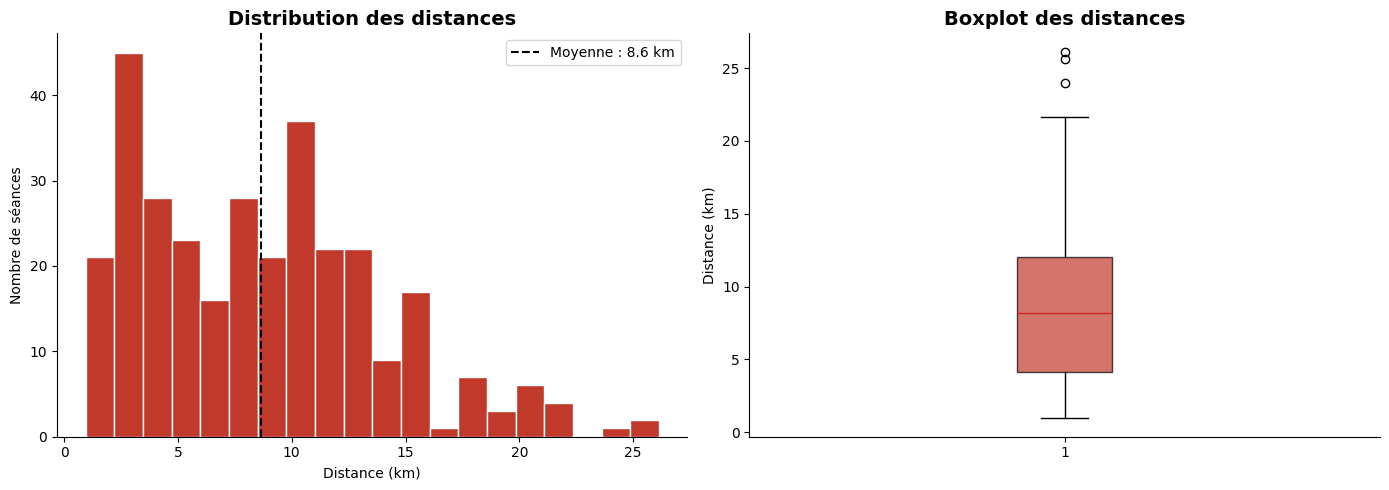

Graphique sauvegardé


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(sessions["distance_km"], bins=20, color="#C0392B", edgecolor="white")
axes[0].set_title("Distribution des distances", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Nombre de séances")
axes[0].axvline(sessions["distance_km"].mean(), color="black", linestyle="--", label=f"Moyenne : {sessions['distance_km'].mean():.1f} km")
axes[0].legend()

# Boxplot
axes[1].boxplot(sessions["distance_km"], patch_artist=True,
                boxprops=dict(facecolor="#C0392B", alpha=0.7))
axes[1].set_title("Boxplot des distances", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Distance (km)")

plt.tight_layout()
plt.savefig("../data/processed/viz_distances.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé")

## Étape 4 — Évolution de la fréquence cardiaque dans le temps

### Pourquoi c'est important
La **fréquence cardiaque moyenne** est l'un des meilleurs indicateurs de l'état de forme d'un athlète. Une FC qui baisse sur une même allure indique une **progression** (le cœur travaille moins pour la même vitesse). Une FC qui monte peut signaler de la **fatigue accumulée** ou un début de surentraînement.

La **ligne de tendance** (pointillée) permet de visualiser l'évolution globale sur 2 ans, au-delà des variations séance à séance.

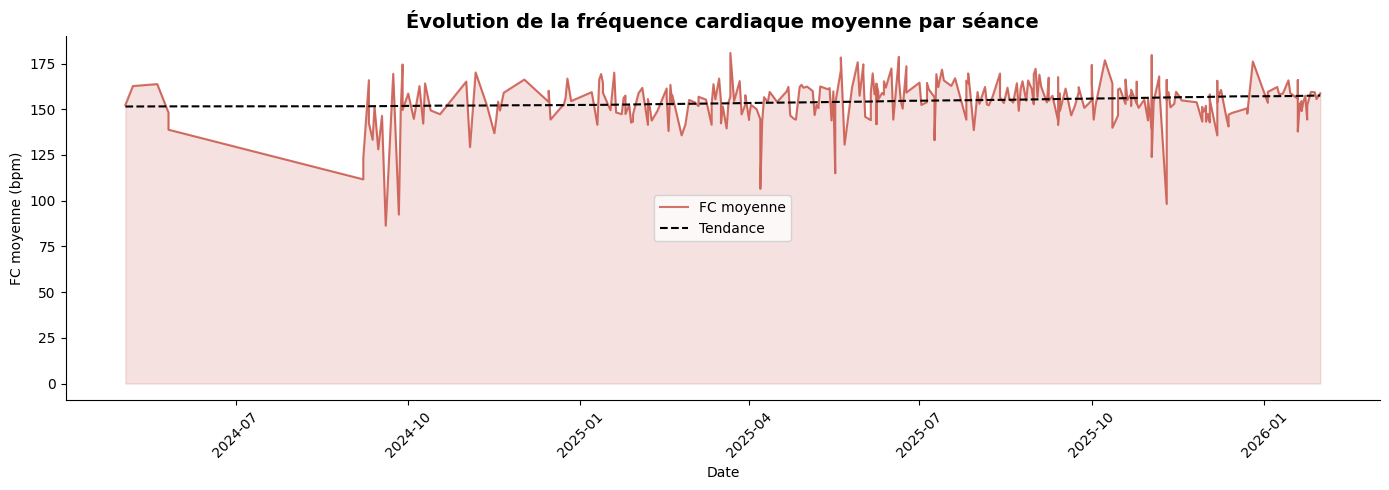

In [5]:
sessions_sorted = sessions.sort_values("date")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sessions_sorted["date"], sessions_sorted["fc_moyenne"],
        color="#C0392B", linewidth=1.5, alpha=0.7, label="FC moyenne")
ax.fill_between(sessions_sorted["date"],
                sessions_sorted["fc_moyenne"],
                alpha=0.15, color="#C0392B")

# Ligne de tendance
z = np.polyfit(range(len(sessions_sorted)), sessions_sorted["fc_moyenne"], 1)
p = np.poly1d(z)
ax.plot(sessions_sorted["date"], p(range(len(sessions_sorted))),
        "--", color="black", linewidth=1.5, label="Tendance")

ax.set_title("Évolution de la fréquence cardiaque moyenne par séance", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("FC moyenne (bpm)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/viz_fc_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## Étape 5 — Analyse de la saisonnalité

### Observations
Cette section analyse la **régularité de l'entraînement** sur 2 ans :

- Le **nombre de séances par mois** révèle les périodes d'activité intense et les creux (blessures, vacances, périodes de compétition)
- La **distance totale mensuelle** montre l'évolution du volume d'entraînement

Ces informations sont cruciales pour comprendre **comment ma charge de travail évolue** au fil des saisons, et serviront de base pour le Feature Engineering (CTL/ATL) dans le Notebook 3.

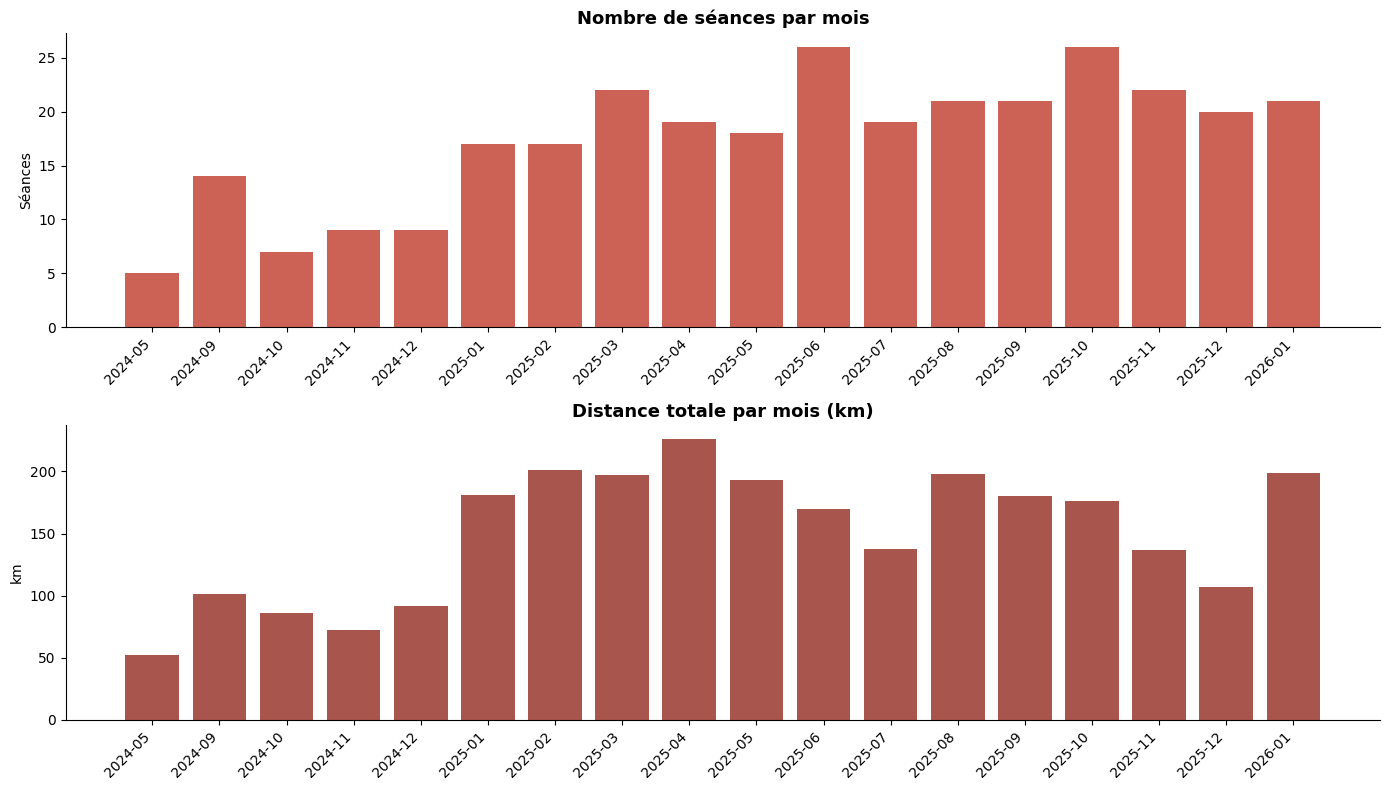

In [6]:
sessions["month_year"] = pd.to_datetime(sessions["date"]).dt.to_period("M").astype(str)
monthly = sessions.groupby("month_year").agg(
    nb_seances    = ("session_file", "count"),
    distance_totale = ("distance_km", "sum"),
    fc_moy        = ("fc_moyenne", "mean")
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Nombre de séances
axes[0].bar(monthly["month_year"], monthly["nb_seances"], color="#C0392B", alpha=0.8)
axes[0].set_title("Nombre de séances par mois", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Séances")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right")

# Distance totale
axes[1].bar(monthly["month_year"], monthly["distance_totale"], color="#922B21", alpha=0.8)
axes[1].set_title("Distance totale par mois (km)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("km")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../data/processed/viz_saisonnalite.png", dpi=150, bbox_inches="tight")
plt.show()

## Étape 6 — Matrice de corrélations

### Lecture de la heatmap
La matrice de corrélations mesure la **force de la relation linéaire** entre chaque paire de variables :
- Une valeur proche de **+1** indique une forte corrélation positive
- Une valeur proche de **-1** indique une forte corrélation négative
- Une valeur proche de **0** indique l'absence de relation linéaire

### Corrélations attendues
- Distance et durée devraient être **fortement corrélées** (plus on court longtemps, plus on va loin)
- FC moyenne et vitesse peuvent être **positivement corrélées** (plus on va vite, plus le cœur travaille)
- La cadence devrait être **relativement stable** (indicateur de style de course)

> Ces corrélations guideront la **sélection des features** pour les modèles Machine Learning du Notebook 4.

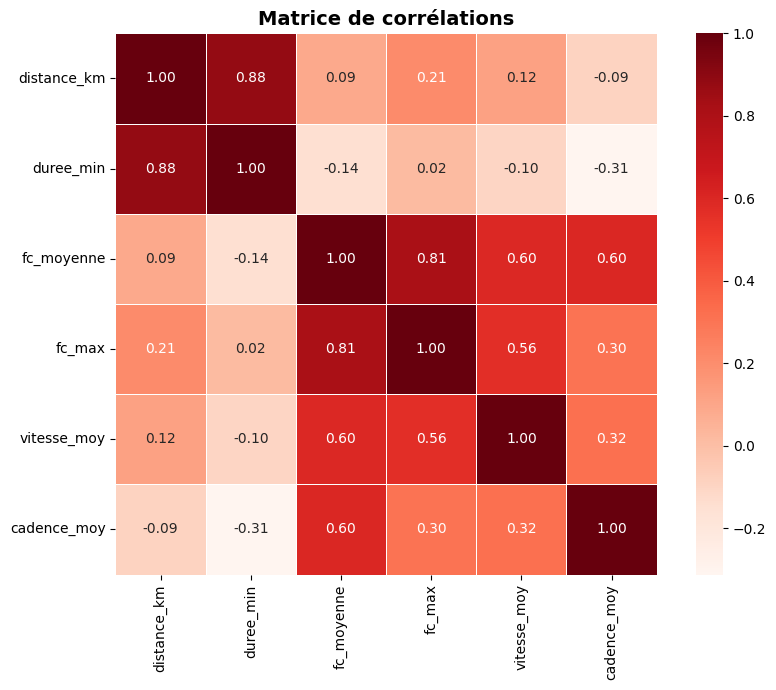

In [7]:
corr_cols = ["distance_km", "duree_min", "fc_moyenne", "fc_max", "vitesse_moy", "cadence_moy"]
corr_matrix = sessions[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Reds",
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Matrice de corrélations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/viz_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Étape 7 — Sauvegarde du dataset propre

Le dataset agrégé et nettoyé est sauvegardé dans `data/processed/sessions_clean.csv`. Ce fichier contient **une ligne par séance** avec toutes les métriques calculées, et servira de base pour :
- Le **Feature Engineering** (Notebook 3)
- Le **Machine Learning** (Notebook 4)

In [8]:
sessions.to_csv("../data/processed/sessions_clean.csv", index=False)
print(f"✅ sessions_clean.csv sauvegardé — {len(sessions)} séances")
print("\nAperçu final :")
sessions.head(10)

✅ sessions_clean.csv sauvegardé — 313 séances

Aperçu final :


,session_file,date,distance_km,duree_min,fc_moyenne,fc_max,vitesse_moy,cadence_moy,allure_min_km,month_year
0,460305244924968960.fit,2024-05-03,12.6285,58.866667,152.366242,188.0,13.141556,82.205797,4.565669,2024-05
1,460391683555622912.fit,2024-05-07,17.6190,72.333333,162.676641,186.0,14.540208,82.676805,4.126488,2024-05
2,460694895898689536.fit,2024-05-20,10.0430,38.833333,163.760189,189.0,15.181373,82.992271,3.952212,2024-05
3,460829317639733248.fit,2024-05-26,10.1345,44.633333,148.194765,181.0,14.019811,80.242868,4.279658,2024-05
4,460829702844612611.fit,2024-05-26,1.6610,8.166667,138.816701,148.0,12.399346,80.357290,4.838965,2024-05
5,463241586826838023.fit,2024-09-07,1.0220,14.700000,111.661765,125.0,5.714712,60.086601,10.499217,2024-09
6,463261131075518467.fit,2024-09-07,1.6710,8.516667,123.070423,143.0,13.099259,NaN,4.580412,2024-09
7,463312871470694402.fit,2024-09-10,4.9675,24.483333,142.495918,158.0,11.881580,80.578231,5.049834,2024-09
8,463312871470694403.fit,2024-09-10,4.7740,21.633333,165.909931,186.0,14.405213,78.276022,4.165159,2024-09
9,463363396394319878.fit,2024-09-12,7.4945,46.450000,133.330700,170.0,9.493555,79.492998,6.320077,2024-09


## Bilan de l'EDA

| Indicateur         |        Valeur          |

| Séances analysées  |           313          |   
| Distance moyenne   |        8,6 km          |
| FC moyenne globale |       154 bpm          |
| Vitesse moyenne    | 13,4 km/h (~4'28" /km) |
| Cadence moyenne    |        81 pas/min      |
| Période couverte   |         2 ans          |

### Points clés observés
- La distribution des distances est **asymétrique à droite** — la majorité des séances sont des sorties moyennes avec quelques longues sorties qui tirent la moyenne vers le haut
- La fréquence cardiaque présente une **variabilité importante** qui reflète les différents types de séances (récupération, endurance fondamentale, fractionnés)
- La corrélation distance/durée est la plus forte, ce qui confirme la cohérence des données

**Prochaine étape** : Notebook 3 — Feature Engineering (CTL, ATL, TSB, TRIMP, Monotonie)